In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
df_spam = pd.read_csv("../data/email_text.csv")
df_spam.head()

,label,text
0,0,the mailing list i queried about a few weeks a...
1,1,luxury watches buy your own rolex for only esc...
2,1,academic qualifications available from prestig...
3,0,greetings all this is to verify your subscript...
4,1,try chauncey may conferred the luscious not co...


In [4]:
df_spam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17309 entries, 0 to 17308
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   17309 non-null  int64 
 1   text    17309 non-null  object
dtypes: int64(1), object(1)
memory usage: 270.6+ KB


In [5]:
print("Dataset Shape:", df_spam.shape)

Dataset Shape: (17309, 2)


In [6]:
print(df_spam.columns.tolist())

['label', 'text']


In [12]:
df_spam.isnull().sum()

label    0
text     0
dtype: int64

In [11]:
print("Empty emails:",
      (df_spam["text"].fillna("").str.strip() == "").sum())

Empty emails: 0


In [13]:
df_spam["label"].value_counts()

label
0    12508
1     4801
Name: count, dtype: int64

In [14]:
print(
    df_spam["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

label
0    72.26
1    27.74
Name: proportion, dtype: float64


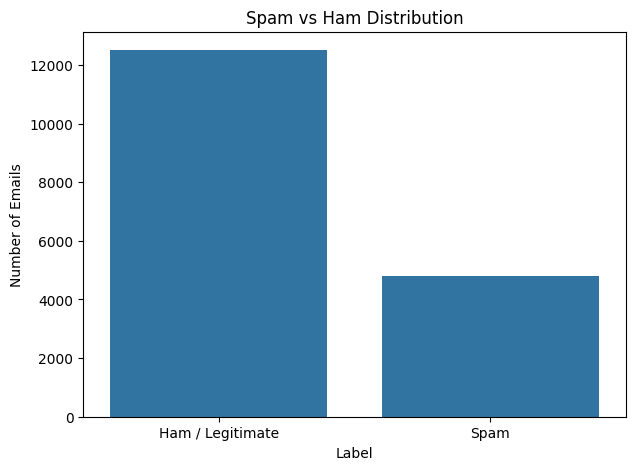

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_spam,
    x="label"
)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Emails")

plt.xticks(
    [0, 1],
    ["Ham / Legitimate", "Spam"]
)

plt.show()

In [16]:
print("Duplicate rows:", df_spam.duplicated().sum())

Duplicate rows: 0


In [17]:
print(
    "Duplicate email texts:",
    df_spam["text"].duplicated().sum()
)

Duplicate email texts: 0


In [18]:
spam_df = df_spam.copy()
spam_df = spam_df.dropna(subset=["text"])
spam_df = spam_df[
    spam_df["text"].str.strip() != ""
]
spam_df = spam_df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

In [19]:
print("Clean dataset shape:", spam_df.shape)

Clean dataset shape: (17309, 2)


In [20]:
spam_df["text_length"] = spam_df["text"].str.len()
spam_df["text_length"].describe()

count    1.730900e+04
mean     2.548157e+03
std      3.582312e+04
min      2.000000e+00
25%      4.240000e+02
50%      8.430000e+02
75%      1.707000e+03
max      3.140726e+06
Name: text_length, dtype: float64

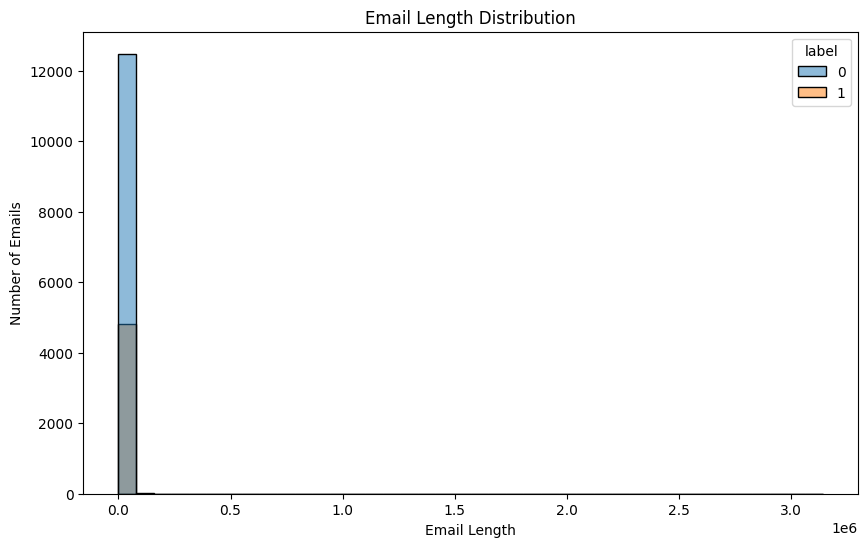

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=spam_df,
    x="text_length",
    hue="label",
    bins=40
)

plt.title("Email Length Distribution")
plt.xlabel("Email Length")
plt.ylabel("Number of Emails")

plt.show()

In [22]:
ham_examples = spam_df[
    spam_df["label"] == 0
].sample(5, random_state=42)

for _, row in ham_examples.iterrows():
    print("=" * 80)
    print(row["text"][:1500])

you don't use lynx newbies on sun escapenumber jan escapenumber drudiescapenumber aol com wrote help how do you get to the great places on the net through pine rudi nevada edu 
hi all when i run my experiemnt the cot seems not match with the total time of the images presented it's always escapenumber escapenumber ticks more i wonder whether it's because of the loading images problem or anything else thanks for help cheers vannessa this message has been checked for viruses but the contents of an attachment may still contain software viruses which could damage your computer system you are advised to perform your own checks email communications with the university of nottingham may be monitored as permitted by uk legislation 
at escapenumber escapenumber escapenumber escapenumber escapenumber escapenumber you wrote hi all i'm running a lexical decision task using a black background and white stimuli on some trials there are white dots on a line below and or above the stimulus what are the

In [23]:
spam_examples = spam_df[
    spam_df["label"] == 1
].sample(5, random_state=42)

for _, row in spam_examples.iterrows():
    print("=" * 80)
    print(row["text"][:1500])

 escapenumberd escapenumbera escapenumberd escapenumbera escapenumberd escapenumbera escapenumber vendare commercial email escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumberd escapenumbera escapenumberd escapenumbera escapenumberd escapenumbera escapenumberd escapenumbera escapenumberd escapenumbera escapenumber email cre ative escapenumberd escapenumbera escapenumber internal escapenumberd escapenumbera escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumber escapenumber escapenumberd escapenumbera escapenumber escapenumber escapenumberd escapenumbera escapenumber tr escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumber escapenumber escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumber escapenumber td escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumber escapenumbe

In [24]:
X = spam_df["text"]
y = spam_df["label"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 13847
Testing samples: 3462


In [27]:
import sys
sys.path.append("../")
from src.preprocessing import preprocess_text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Raj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Raj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Raj\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [28]:
X_train_clean = X_train.apply(preprocess_text)
X_test_clean = X_test.apply(preprocess_text)

In [29]:
print(X_train_clean.head())

12070    hi jerry certainly worked lot make everything ...
15668    begin pgp signed message hash shaescapenumber ...
9623              put plan escapenumber software page like
7901     thanks fred yes several working one download b...
12611    marshall one best set vendor price seen monarc...
Name: text, dtype: object


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
spam_tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
X_train_tfidf = spam_tfidf.fit_transform(
    X_train_clean
)
X_test_tfidf = spam_tfidf.transform(
    X_test_clean
)

In [31]:
print("Training TF-IDF:", X_train_tfidf.shape)
print("Testing TF-IDF:", X_test_tfidf.shape)

Training TF-IDF: (13847, 10000)
Testing TF-IDF: (3462, 10000)


In [32]:
from sklearn.naive_bayes import MultinomialNB

spam_nb = MultinomialNB()

spam_nb.fit(
    X_train_tfidf,
    y_train
)
spam_nb_predictions = spam_nb.predict(
    X_test_tfidf
)

In [33]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
nb_spam_accuracy = accuracy_score(
    y_test,
    spam_nb_predictions
)

print(
    "Naive Bayes Spam Accuracy:",
    nb_spam_accuracy
)

Naive Bayes Spam Accuracy: 0.9364529173887927


In [34]:
print(
    classification_report(
        y_test,
        spam_nb_predictions,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.93      0.99      0.96      2502
        Spam       0.96      0.81      0.88       960

    accuracy                           0.94      3462
   macro avg       0.94      0.90      0.92      3462
weighted avg       0.94      0.94      0.93      3462



In [ ]:
from sklearn.svm import LinearSVC

spam_svm = LinearSVC(
    C=1.0,
    random_state=42
)

spam_svm.fit(
    X_train_tfidf,
    y_train
)
spam_svm_predictions = spam_svm.predict(
    X_test_tfidf
)